# a06 Example - Gradient Descent Optimization Scan with Inverted Objective and Bounds

In [1]:
import pyscan as ps
import numpy as np
import matplotlib.pyplot as plt

## Setup devices

In [2]:
devices = ps.ItemAttribute()

devices.v1 = ps.TestVoltage() # Device 1
devices.v2 = ps.TestVoltage() # Device 2

## Define a measure function

In [3]:
def voltage_response(v1, v2):
    """
    Paraboloid function to optimize.
    """
    return (v1 - 4)**2 + (v2 - 6)**2

def get_voltage_data(expt):
    """
    Reads the voltage from v1 and v2. Also adds a calculated voltage response to optimize.
    """

    runinfo = expt.runinfo
    devices = expt.devices

    d = ps.ItemAttribute()

    d.v1_readout = devices.v1.voltage
    d.v2_readout = devices.v2.voltage

    d.vf = -1 * voltage_response(d.v1_readout, d.v2_readout)

    return d

# Define live plot

In [4]:
@ps.live_plot
def plot_optim_live(expt):
    global fig, ax, cb0, cb1
    x, y = np.mgrid[0:10:.01, 0:10:.01]
    z = np.array(voltage_response(np.ravel(x), np.ravel(y)))
    z = z.reshape(x.shape)
    pcm = ax.pcolormesh(x, y, z, cmap='gist_heat')
    scatter = ax.scatter(expt.v1_readout, expt.v2_readout, c=range(len(expt.v1_readout)),
                         cmap='viridis')
    ax.set_box_aspect(1)
    if cb0 is None and cb1 is None:
        cb0 = fig.colorbar(scatter, label="optimizer step")
        cb1 = fig.colorbar(pcm, label="voltage response")
    else:
        cb0.update_normal(scatter)
    ax.legend(["optimizer decision process",], loc='lower left', bbox_to_anchor=(.1, -.3))
    ax.set_xlabel("v1_readout")
    ax.set_ylabel("v2_readout")
    ax.set_title("Optimization of Voltage Response")

# Define runinfo

In [5]:
runinfo = ps.RunInfo()
runinfo.measure_function = get_voltage_data

# Extend `OptimizeDeviceProperty` with `GradientDescentOptimizeDeviceProperty`

# Instantiate `GradientDescentOptimizeDeviceProperty`

In [6]:
v1 = ps.GradientDescentOptimizeDeviceProperty('v1', 'voltage', 8.,
                                              1e-1, 1e-1, 1e-1,
                                              optimizer_input='v1_readout',
                                              bounds=(0., 10.))
v2 = ps.GradientDescentOptimizeDeviceProperty('v2', 'voltage', 3.,
                                              1e-1, 1e-1, 1e-1,
                                              optimizer_input='v2_readout',
                                              bounds=(0., 10.))

# Implement `AbstractOptimizeScan` with `GradientDescentOptimizeScan`

# Instantiate `GradientDescentOptimizeScan`

In [7]:
runinfo.scan0 = ps.optimizers.GradientDescentOptimizeScan((v1, v2),
                                                          'vf',
                                                          dt=1., n_max=100)

# Run Experiments

In [8]:
expt = ps.Experiment(runinfo, devices)
expt.start_thread()

Stopping Experiment


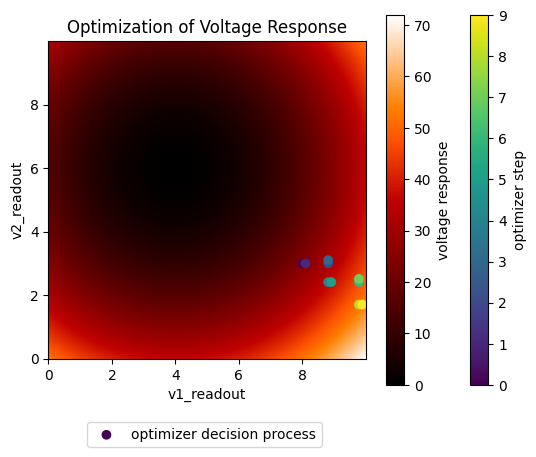

In [9]:
fig, ax = plt.subplots()
cb0 = cb1 = None
try:
    plot_optim_live(expt)
except KeyboardInterrupt:
    expt.stop()

In [10]:
expt.__dict__

{'runinfo': <pyscan.measurement.run_info.RunInfo at 0x1bdb10f0d10>,
 'devices': <itemattribute.item_attribute.ItemAttribute at 0x1bdb1031370>,
 'expt_thread': <Thread(Thread-3 (run), stopped daemon 25236)>,
 'iteration': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 'v1_voltage': array([ 8.   ,  8.1  ,  8.81 ,  8.81 ,  8.81 ,  8.91 ,  9.782,  9.782,
         9.782,  9.882, 10.   ]),
 'v2_voltage': array([3.   , 3.   , 3.   , 3.1  , 2.41 , 2.41 , 2.41 , 2.51 , 1.702,
        1.702, 1.702]),
 'v1_readout': array([ 8.   ,  8.1  ,  8.81 ,  8.81 ,  8.81 ,  8.91 ,  9.782,  9.782,
         9.782,  9.882, 10.   ]),
 'v2_readout': array([3.   , 3.   , 3.   , 3.1  , 2.41 , 2.41 , 2.41 , 2.51 , 1.702,
        1.702, 1.702]),
 'vf': array([-25.      , -25.81    , -32.1361  , -31.5461  , -36.0242  ,
        -36.9962  , -46.319624, -45.611624, -51.904328, -53.070728,
        -54.472804])}

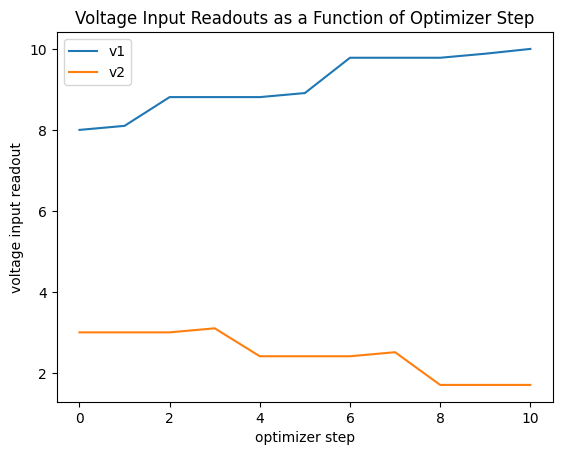

In [11]:
plt.plot(list(zip(expt.v1_readout, expt.v2_readout)))
plt.legend(['v1', 'v2'])
plt.xlabel("optimizer step")
plt.ylabel("voltage input readout")
plt.title("Voltage Input Readouts as a Function of Optimizer Step");

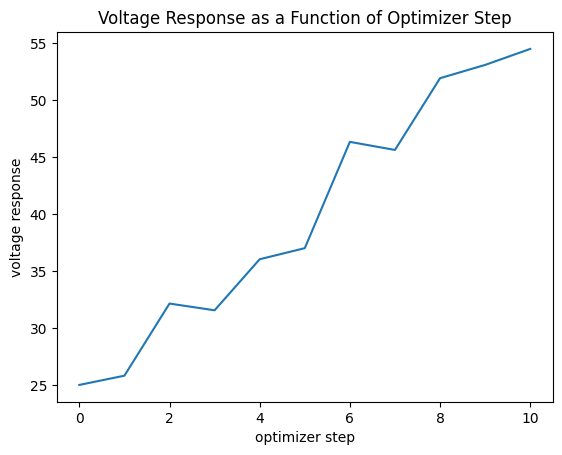

In [12]:
plt.plot(-1 * expt.vf)
plt.xlabel("optimizer step")
plt.ylabel("voltage response")
plt.title("Voltage Response as a Function of Optimizer Step");

In [13]:
def plot_optim_pcm():
    fig, ax = plt.subplots()
    x, y = np.mgrid[0:10:.01, 0:10:.01]
    z = np.array(voltage_response(np.ravel(x), np.ravel(y)))
    z = z.reshape(x.shape)
    pcm = ax.pcolormesh(x, y, z, cmap='gist_heat')
    scatter = ax.scatter(expt.v1_readout, expt.v2_readout, c=range(len(expt.v1_readout)),
                         cmap='viridis')
    ax.set_box_aspect(1)
    fig.colorbar(scatter, label="optimizer step")
    fig.colorbar(pcm, label="voltage response")
    ax.legend(["optimizer decision process",], loc='lower left', bbox_to_anchor=(.1, -.3))
    ax.set_xlabel("v1_readout")
    ax.set_ylabel("v2_readout")
    ax.set_title("Optimization of Voltage Response")

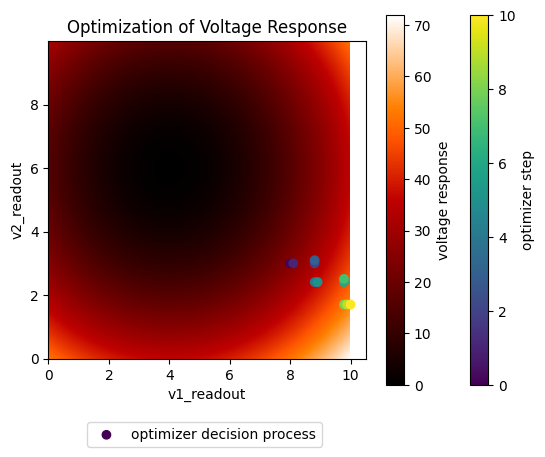

In [14]:
plot_optim_pcm()

In [15]:
def plot_optim_3d(elevation, azimuth):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    x, y = np.mgrid[0:10:.01, 0:10:.01]
    z = np.array(voltage_response(np.ravel(x), np.ravel(y)))
    z = z.reshape(x.shape)
    ax.plot_surface(x, y, z, color='C1', alpha=.5)
    scatter = ax.scatter(expt.v1_readout, expt.v2_readout, -1 * expt.vf, c=range(len(expt.v1_readout)))
    ax.view_init(elev=elevation, azim=azimuth)
    fig.colorbar(scatter, label="optimizer step", pad=.1)
    ax.legend(["voltage response function", "optimizer decision process",], loc='lower left', bbox_to_anchor=(.2, -.2))
    ax.set_xlabel("v1_readout")
    ax.set_ylabel("v2_readout")
    ax.set_zlabel("voltage response")
    ax.set_title("Optimization of Voltage Response")

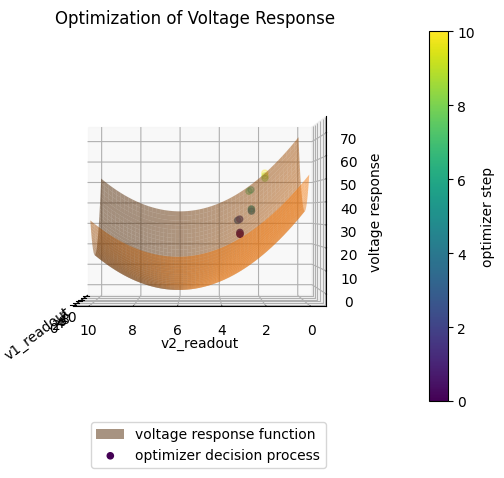

In [16]:
plot_optim_3d(0, 180)

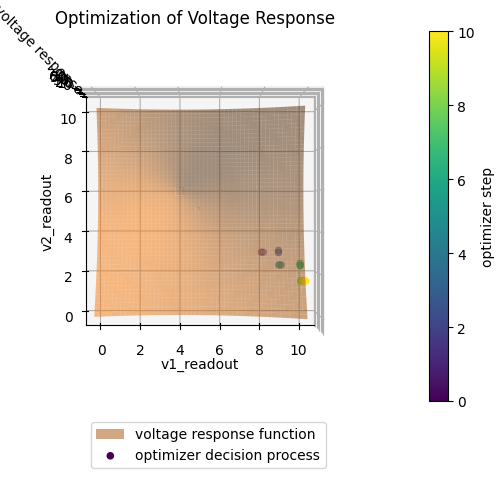

In [17]:
plot_optim_3d(90, 270)

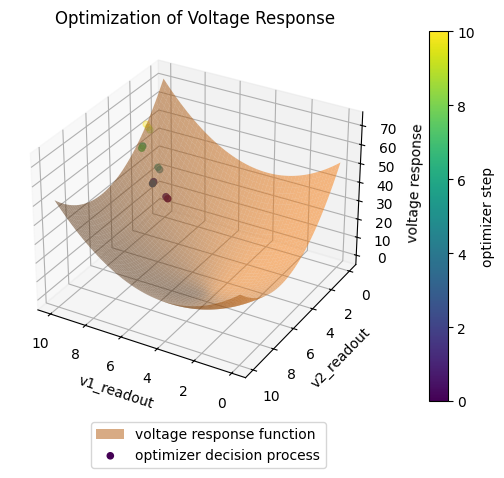

In [18]:
plot_optim_3d(30, 120)